In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,accuracy_score
from joblib import dump, load

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import mode
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import fetch_openml

from xai_aux import CFCalculations
from xai_aux import simulate_noise_effect

In [2]:
warnings.filterwarnings("ignore", message="X has feature names, but RandomForestClassifier was fitted without feature names")
warnings.filterwarnings("ignore", message="X has feature names, but LogisticRegression was fitted without feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but OneHotEncoder was fitted with feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but StandardScaler was fitted with feature names")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*At this time, the v2.11\\+ optimizer.*")

In [3]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.data

categorical_columns = ["workclass", "education", "marital-status", "occupation",
            "relationship", "race", "sex", "native-country"]
numerical_columnns = [col for col in df.columns if col not in categorical_columns]
df = df[categorical_columns + numerical_columnns]
df["native-country"] = df["native-country"].apply(lambda x: "usa" if x == "United-States" else "non_usa")

# Reorder columns: categorical first, numerical after
df = df[categorical_columns + numerical_columnns]
df = df.drop(columns=["fnlwgt","sex","race"])

# Encode target variable
le = LabelEncoder()
adult.target = le.fit_transform(adult.target)

# Convert to NumPy array
y = np.array(adult.target)
df['y'] = y
df = df.dropna()
df= df.sample(frac=0.2)
y = df.pop('y')
y = y.values

num_feat = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_feat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']

In [4]:
min_frequency = 300

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


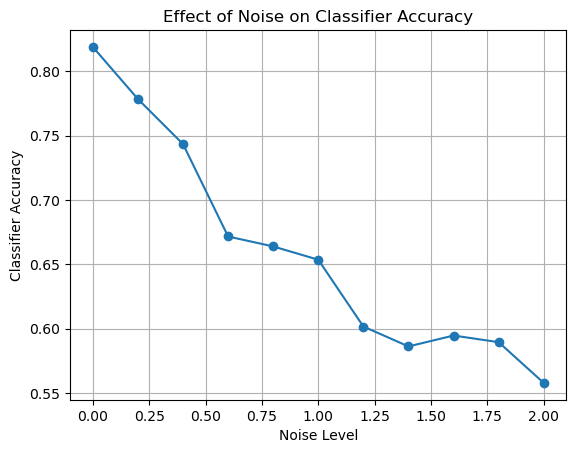

In [5]:
results, datasets = simulate_noise_effect(df, num_feat, cat_feat, y, max_noise=2., step=0.2, min_frequency=min_frequency)
noise_levels, accuracies = zip(*results)
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel('Noise Level')
plt.ylabel('Classifier Accuracy')
plt.title('Effect of Noise on Classifier Accuracy')
plt.grid()
plt.show()

In [6]:
n_features = len(df.columns)

In [7]:
def get_polytopes(enc):
    # Get transformed feature names
    feature_names = enc.get_feature_names_out()
    #print("Encoded Feature Names:", feature_names)  # Debugging step

    # Extract number of features per original category
    feature_counts = []
    current_feature = None
    count = 0

    for feature in feature_names:
        original_category = feature.split("_")[0]  # Extract the original category index
        if original_category != current_feature:
            if count > 0:  # Append count for previous category
                feature_counts.append(count)
            current_feature = original_category
            count = 1  # Start counting for new category
        else:
            count += 1
    feature_counts.append(count)  # Append the last count

    # Generate list of lists with sequential numbering
    start = 1
    polytopes = []

    for count in feature_counts:
        if count>1:
            polytopes.append(list(range(start, start + count)))
            start += count

    #print("Final polytopes:", polytopes)
    return polytopes

In [8]:
# cat_feat2 = [str(i) for i in range(len(cat_feat))][0:6]
# enc = OneHotEncoder(drop='first', min_frequency=min_frequency, sparse_output=False)
# enc.fit(df_train[cat_feat2])
# X_enc = pd.DataFrame(np.hstack([np.ones((len(df_train),1)), enc.transform(df_train[cat_feat2])]))
# polytopes = get_polytopes(enc)

In [9]:
model_results_dict = {}
cf_results_dict = {}
cm_results_dict = {}
cfs_good_indices = {}
for c1, dataset_in in enumerate(datasets):
    print("Working on dataset ", str(c1))
    X = dataset_in[0]
    y = dataset_in[1]
    df = pd.DataFrame(X.values, columns=[str(i) for i in range(n_features)])
    df_train, df_test, y_train, y_test, indices_train, indices_test = train_test_split(df, y, np.arange(len(X)), test_size=0.33, random_state=42)
    
    cat_feat2 = [str(i) for i in range(len(cat_feat))]
    enc = OneHotEncoder(drop='first', min_frequency=min_frequency, sparse_output=False)
    enc.fit(df_train[cat_feat2])
    X_enc = pd.DataFrame(np.hstack([np.ones((len(df_train),1)), enc.transform(df_train[cat_feat2])]))
    polytopes = get_polytopes(enc)
    
    # # ommitted variables change
    # df_train = df_train.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    # df_test = df_test.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    # num_feat = [4,5,6]
    # cat_feat = [0,1,2,3]
    
    # if non_iid:
    #     outlier_indices = np.random.choice(len(df_test), n_samples//10, replace=False)
    #     df_test.iloc[outlier_indices, 5:] *= 5
    
    cf_calc = CFCalculations(
        df_train,
        y_train, 
        df_test, 
        y_test,
        [int(i) for i in range(6)], 
        [int(i) for i in range(6,11)], 
        polytopes, 
        do_marg=False,
        do_dice=True,
        min_frequency=min_frequency) 
        
    print(pd.DataFrame([(model, metric, value) for (model, metric), value in cf_calc.model_stats.items()], 
                       columns=['Model', 'Metric', 'Value']))
    model_results_dict[f"noise_{c1:.0f}"] = cf_calc.model_stats
    cm_results_dict[f"noise_{c1:.0f}"] = cf_calc.cms
    cfs = cf_calc.get_cfs()
    cfs_good_indices[f"noise_{c1:.0f}"] = cf_calc.check_cfs()
    cf_results_dict[f"noise_{c1:.0f}"] = cfs

    dump(cf_calc, "cf_calc_adult_income.pkl")
    dump(cf_results_dict, "cf_results_dict_adult_income.pkl")
    dump(model_results_dict, "model_results_adult_income.pkl")
    dump(cfs_good_indices, "cfs_good_indices_adult_income.pkl")
    # dump(datasets, "datasets_"+str(mock_data)+"_adult_income.pkl")
    print("==================================================================================================")

Working on dataset  0


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 276 seconds.


94/94 [==============================] - 0s 439us/step - loss: 0.3983 - accuracy: 0.8332 - precision: 0.6814
TF Test Accuracy: 83.32%
94/94 [==============================] - 0s 379us/step
  Model     Metric     Value
0    lr   accuracy  0.834171
1    lr  precision  0.827143
2   blr   accuracy  0.834506
3   blr  precision  0.827536
4    rf   accuracy  0.835846
5    rf  precision  0.830889
6    tf   accuracy  0.833166
7    tf  precision  0.829840
Working on lr skl
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
optimization error - returning original array
Working on lr blr_mean
opt

100%|██████████| 2985/2985 [03:05<00:00, 16.10it/s]


Working on lr RL


...

Counterfactuals calculated
Checking CFs...
CFs for linear model not ok
Number or wrong CFs: 10 ( 0.33500837520938026 %)
CFs for bayesian mean linear model not ok
Number or wrong CFs: 10 ( 0.33500837520938026 %)
CFs for nice linear model ok
CFs for dice linear model ok
CFs for RL linear model not ok
Number or wrong CFs: 2896 ( 97.01842546063652 %)
CFs for nice rf model ok


/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


CFs for dice rf model not ok
Number or wrong CFs: 213 ( 7.135678391959799 %)
CFs for RL rf model not ok
Number or wrong CFs: 2461 ( 82.44556113902847 %)
94/94 [==============================] - 0s 356us/step


/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


CFs for nice tf model ok
94/94 [==============================] - 0s 343us/step
CFs for dice tf model ok
CFs checked


In [10]:
# Apply value_counts() to each column and filter counts greater than n
value_counts_filtered = {col: X[cat_feat][col].value_counts()[X[cat_feat][col].value_counts() >= 100] for col in X[cat_feat].columns}

# Remove empty results (columns where no values meet the condition)
value_counts_filtered = {col: counts for col, counts in value_counts_filtered.items() if not counts.empty}

# Print results
for col, counts in value_counts_filtered.items():
    print(f"Column: {col}\n{counts}\n")

Column: workclass
workclass
Private             6650
Self-emp-not-inc     755
Local-gov            645
State-gov            364
Self-emp-inc         347
Federal-gov          277
Name: count, dtype: int64

Column: education
education
HS-grad         2914
Some-college    1966
Bachelors       1519
Masters          489
Assoc-voc        411
11th             331
Assoc-acdm       326
10th             228
7th-8th          170
Prof-school      170
9th              144
5th-6th          112
Doctorate        108
12th             100
Name: count, dtype: int64

Column: marital-status
marital-status
Married-civ-spouse       4208
Never-married            2929
Divorced                 1210
Separated                 303
Widowed                   252
Married-spouse-absent     138
Name: count, dtype: int64

Column: occupation
occupation
Craft-repair         1265
Prof-specialty       1196
Exec-managerial      1159
Adm-clerical         1093
Sales                1077
Other-service         943
Machine-op-insp

In [11]:
cat_feat2 = [str(i) for i in range(len(cat_feat))]
enc = OneHotEncoder(drop='first', min_frequency=300, sparse_output=False)
enc.fit(df_train[cat_feat2])
X_enc = pd.DataFrame(np.hstack([np.ones((len(df_train),1)), enc.transform(df_train[cat_feat2])]))
polytopes = get_polytopes(enc)
polytopes

[[1, 2, 3],
 [4, 5, 6, 7],
 [8, 9, 10],
 [11, 12, 13, 14, 15, 16, 17, 18],
 [19, 20, 21, 22]]

In [12]:
enc.get_feature_names_out()

array(['0_Private', '0_Self-emp-not-inc', '0_infrequent_sklearn',
       '1_HS-grad', '1_Masters', '1_Some-college', '1_infrequent_sklearn',
       '2_Married-civ-spouse', '2_Never-married', '2_infrequent_sklearn',
       '3_Craft-repair', '3_Exec-managerial', '3_Machine-op-inspct',
       '3_Other-service', '3_Prof-specialty', '3_Sales',
       '3_Transport-moving', '3_infrequent_sklearn', '4_Not-in-family',
       '4_Own-child', '4_Unmarried', '4_infrequent_sklearn', '5_usa'],
      dtype=object)

In [13]:
df_train['5'].value_counts()

5
usa        5538
non_usa     521
Name: count, dtype: int64